In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('WA_Fn-UseC_-HR-Employee-Attrition.csv.xlsx')
print('Data loaded successfully')
print(df.shape)
print(df.columns.tolist())

Data loaded successfully
(1470, 35)
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [6]:
##   Age Group Analysis

df['AgeGroup'] = pd.cut(df['Age'], 
    bins=[18, 25, 35, 45, 60],
    labels=['18-25', '26-35', '36-45', '46-60'])
age_attrition = df.groupby('AgeGroup')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY AGE GROUP ===")
print(age_attrition)

=== ATTRITION RATE BY AGE GROUP ===
AgeGroup
18-25    34.78
26-35    19.14
36-45     9.19
46-60    12.45
Name: Attrition, dtype: float64


C:\Users\HP\AppData\Local\Temp\ipykernel_9808\249619377.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_attrition = df.groupby('AgeGroup')['Attrition'].apply(


In [7]:
##  Salary Analysis

print("=== SALARY ANALYSIS ===")
print(f"Average Monthly Income: ${df['MonthlyIncome'].mean():,.2f}")
print(f"Average Income (Left): ${df[df['Attrition']=='Yes']['MonthlyIncome'].mean():,.2f}")
print(f"Average Income (Stayed): ${df[df['Attrition']=='No']['MonthlyIncome'].mean():,.2f}")
salary_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print("\nAverage Salary by Job Role:")
print(salary_by_role.round(2))

=== SALARY ANALYSIS ===
Average Monthly Income: $6,502.93
Average Income (Left): $4,787.09
Average Income (Stayed): $6,832.74

Average Salary by Job Role:
JobRole
Manager                      17181.68
Research Director            16033.55
Healthcare Representative     7528.76
Manufacturing Director        7295.14
Sales Executive               6924.28
Human Resources               4235.75
Research Scientist            3239.97
Laboratory Technician         3237.17
Sales Representative          2626.00
Name: MonthlyIncome, dtype: float64


In [8]:
##   Years at Company Analysis

years_attrition = df.groupby('YearsAtCompany')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY YEARS AT COMPANY ===")
print(years_attrition.head(20))

=== ATTRITION RATE BY YEARS AT COMPANY ===
YearsAtCompany
0     36.36
1     34.50
2     21.26
3     15.62
4     17.27
5     10.71
6     11.84
7     12.22
8     11.25
9      9.76
10    15.00
11     6.25
12     0.00
13     8.33
14    11.11
15     5.00
16     8.33
17    11.11
18     7.69
19     9.09
Name: Attrition, dtype: float64


In [9]:
##  Work Life Balance Analysis

wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY WORK LIFE BALANCE ===")
print("1=Bad, 2=Good, 3=Better, 4=Best")
print(wlb_attrition)

=== ATTRITION RATE BY WORK LIFE BALANCE ===
1=Bad, 2=Good, 3=Better, 4=Best
WorkLifeBalance
1    31.25
2    16.86
3    14.22
4    17.65
Name: Attrition, dtype: float64


In [10]:
##   Job Satisfaction Analysis

js_attrition = df.groupby('JobSatisfaction')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY JOB SATISFACTION ===")
print("1=Low, 2=Medium, 3=High, 4=Very High")
print(js_attrition)

=== ATTRITION RATE BY JOB SATISFACTION ===
1=Low, 2=Medium, 3=High, 4=Very High
JobSatisfaction
1    22.84
2    16.43
3    16.52
4    11.33
Name: Attrition, dtype: float64


In [11]:
##   Overtime Analysis

overtime_attrition = df.groupby('OverTime')['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY OVERTIME ===")
print(overtime_attrition)

=== ATTRITION RATE BY OVERTIME ===
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


In [12]:
##  Department and Gender Analysis


dept_gender = df.groupby(['Department', 'Gender'])['Attrition'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100).round(2)
print("=== ATTRITION RATE BY DEPARTMENT AND GENDER ===")
print(dept_gender)

=== ATTRITION RATE BY DEPARTMENT AND GENDER ===
Department              Gender
Human Resources         Female    30.00
                        Male      13.95
Research & Development  Female    11.35
                        Male      15.46
Sales                   Female    20.11
                        Male      21.01
Name: Attrition, dtype: float64


In [13]:
## Visualization

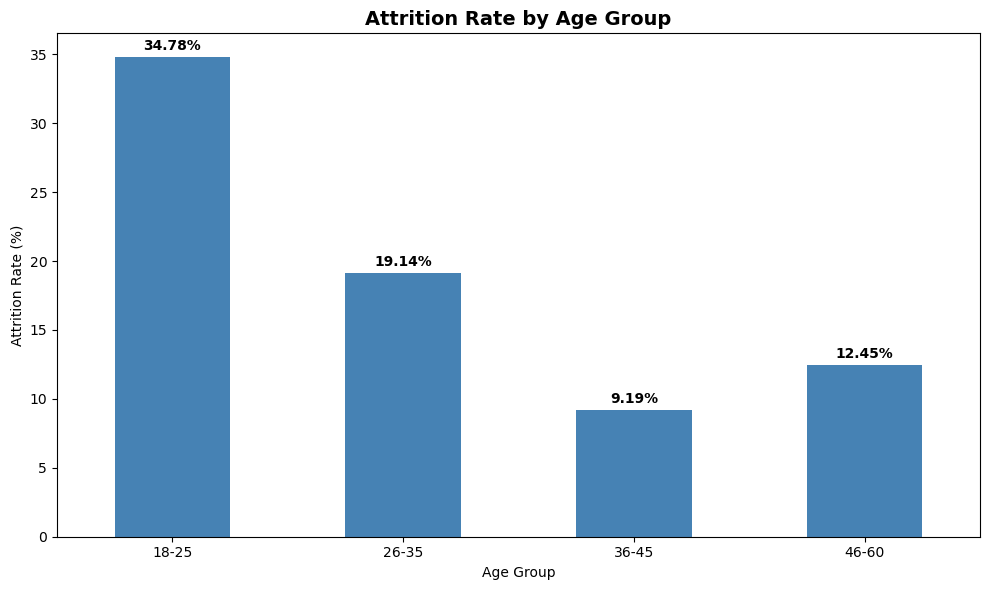

In [14]:
 ##  Attrition Rate by Age Group

plt.figure(figsize=(10,6))
age_attrition.plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(age_attrition):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

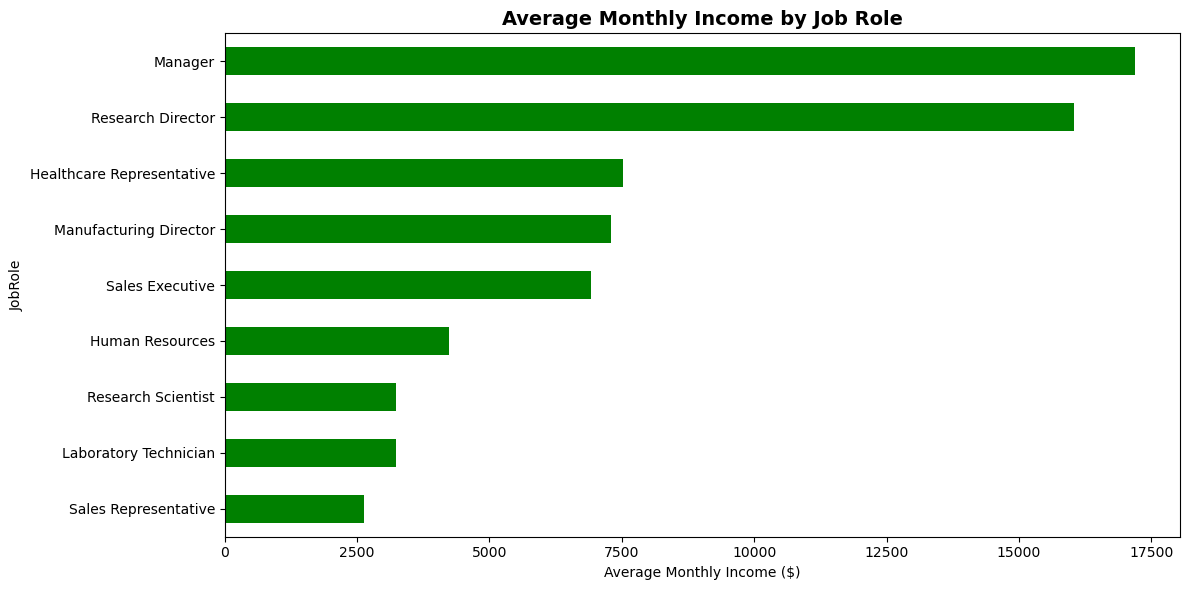

In [15]:
## Salary by Job Role


plt.figure(figsize=(12,6))
salary_by_role.sort_values().plot(kind='barh', color='green')
plt.title('Average Monthly Income by Job Role', fontsize=14, fontweight='bold')
plt.xlabel('Average Monthly Income ($)')
plt.tight_layout()
plt.show()

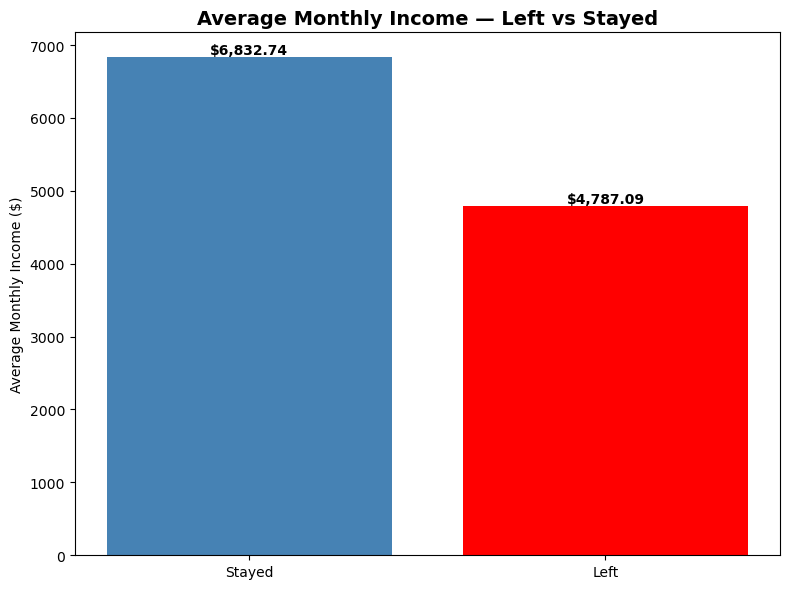

In [16]:
##  Income Left vs Stayed

labels = ['Stayed', 'Left']
values = [6832.74, 4787.09]
plt.figure(figsize=(8,6))
plt.bar(labels, values, color=['steelblue', 'red'])
plt.title('Average Monthly Income — Left vs Stayed', fontsize=14, fontweight='bold')
plt.ylabel('Average Monthly Income ($)')
for i, v in enumerate(values):
    plt.text(i, v+50, f'${v:,.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

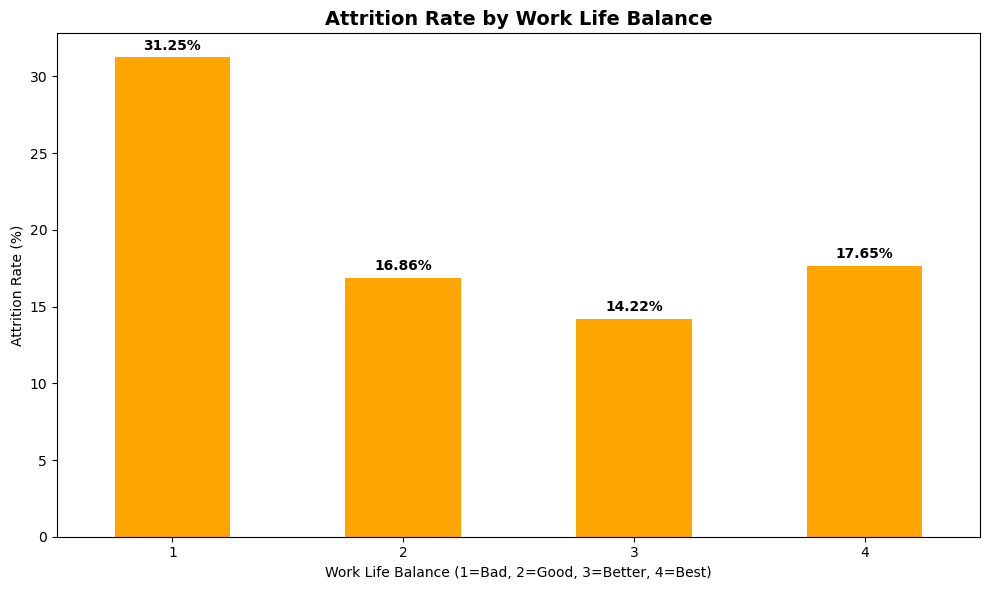

In [17]:
##  Work Life Balance vs Attrition

plt.figure(figsize=(10,6))
wlb_attrition.plot(kind='bar', color='orange')
plt.title('Attrition Rate by Work Life Balance', fontsize=14, fontweight='bold')
plt.xlabel('Work Life Balance (1=Bad, 2=Good, 3=Better, 4=Best)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(wlb_attrition):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

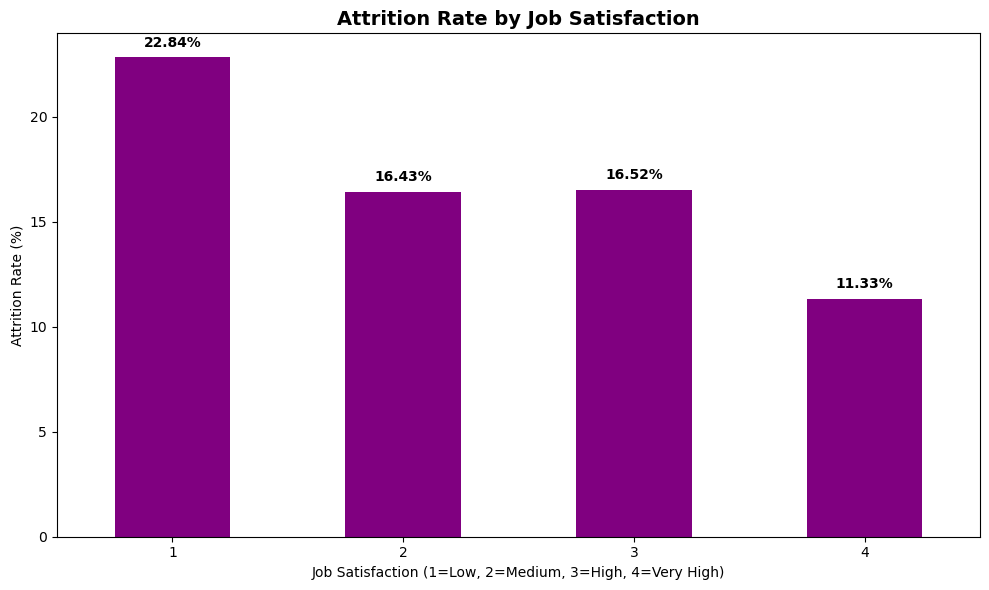

In [18]:
##   Job Satisfaction vs Attrition

plt.figure(figsize=(10,6))
js_attrition.plot(kind='bar', color='purple')
plt.title('Attrition Rate by Job Satisfaction', fontsize=14, fontweight='bold')
plt.xlabel('Job Satisfaction (1=Low, 2=Medium, 3=High, 4=Very High)')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(js_attrition):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

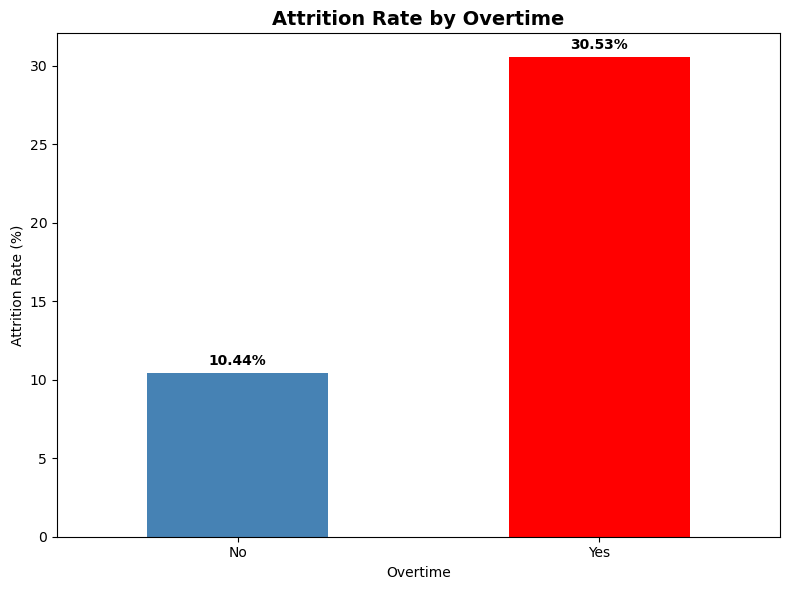

In [19]:
## Overtime vs Attrition

plt.figure(figsize=(8,6))
overtime_attrition.plot(kind='bar', color=['steelblue', 'red'])
plt.title('Attrition Rate by Overtime', fontsize=14, fontweight='bold')
plt.xlabel('Overtime')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(overtime_attrition):
    plt.text(i, v+0.5, f'{v}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

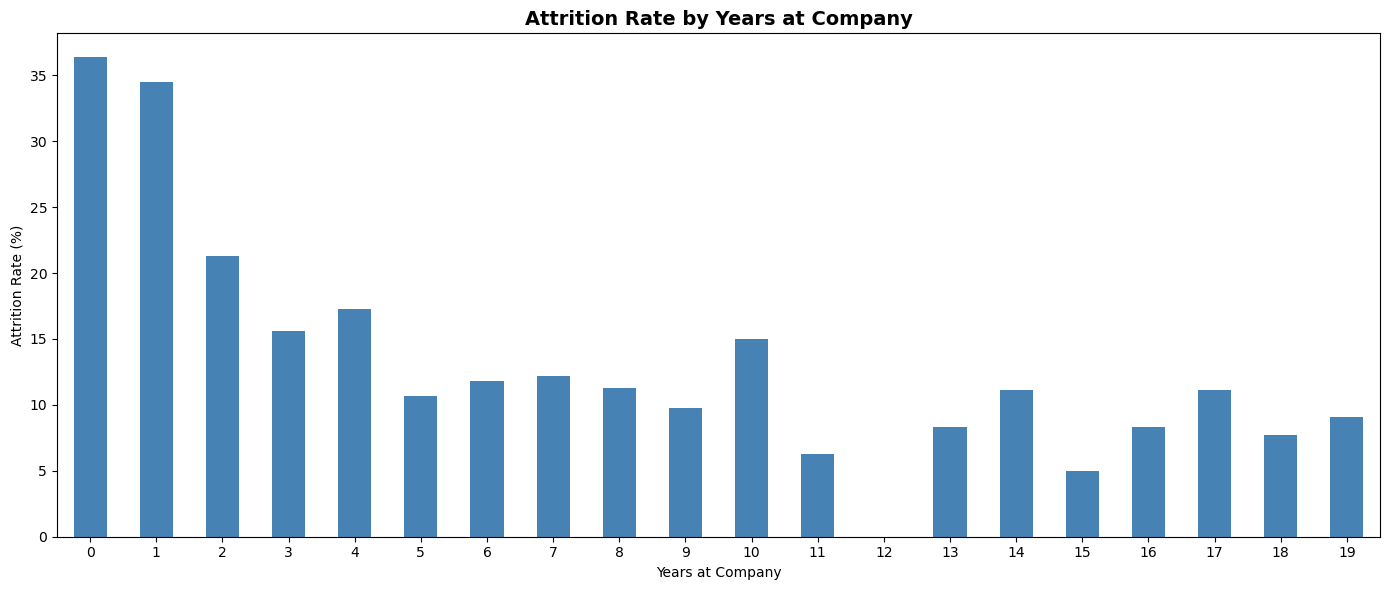

In [20]:
##  Years at Company vs Attrition

plt.figure(figsize=(14,6))
years_attrition.head(20).plot(kind='bar', color='steelblue')
plt.title('Attrition Rate by Years at Company', fontsize=14, fontweight='bold')
plt.xlabel('Years at Company')
plt.ylabel('Attrition Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
df.to_csv('hr_attrition_cleaned.csv', index=False)
print('File saved successfully')

File saved successfully
